<a href="https://colab.research.google.com/github/wlrjs1300-coder/AI_26/blob/main/07_03_%EC%9D%B8%EA%B3%B5%EC%8B%A0%EA%B2%BD%EB%A7%9D%EA%B8%B0%ED%83%80%EB%8F%84%EA%B5%AC(%EB%93%9C%EB%A1%AD%EC%95%84%EC%9B%83%2C%EC%BD%9C%EB%B0%B1%2C%EC%A1%B0%EA%B8%B0%EC%A2%85%EB%A3%8C).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 인공신경망 모델을 만들고 사용하는 전체 흐름

# 1. 더미 데이터 준비
# 실제 데이터 대신 연습용 데이터를 만든다.
# 모델이 어떻게 학습되는지 실험하기 위한 재료라고 생각하면 된다.

# 2. 데이터를 3가지 용도로 나눈다
# 훈련 데이터(train)  : 모델이 공부하는 데이터
# 검증 데이터(val)   : 학습 중간에 성능을 확인하는 데이터
# 테스트 데이터(test): 학습이 끝난 후 최종 성능을 평가하는 데이터

# 3. Dense 층(완전 연결층)을 만든다
# Dense는 뉴런들이 서로 모두 연결된 층이다.
# 입력 데이터를 받아 계산하는 신경망의 기본 구조를 만드는 단계이다.

# 4. 만든 층들을 모델(Model)에 등록한다
# 여러 층을 하나의 신경망 구조로 묶어주는 단계이다.(Sequential)

# 5. 모델 컴파일
# 모델이 학습할 준비를 하는 단계
# - optimizer : 가중치를 어떻게 업데이트할지 결정 (여기서는 Adam 사용)
# - loss      : 틀린 정도를 계산하는 방법
# - metrics   : 성능을 평가하는 기준

# 6. fit() : 모델 훈련
# 훈련 데이터를 사용해 가중치(weight)를 계속 수정하면서
# 모델이 정답을 잘 맞히도록 학습하는 과정이다.

# 7. evaluate() : 모델 평가
# 학습에 사용하지 않았던 데이터로
# 모델의 실제 성능(정확도, 손실 등)을 확인한다.

# 8. predict() : 예측
# 새로운 데이터를 입력하면
# 모델이 어떤 결과를 예측하는지 확인한다.

In [2]:
# 모델을 fit()으로 학습시키면 학습 과정이 화면에 출력된다.
# 예를 들어 다음과 같은 정보가 매 에포크(epoch)마다 나타난다.
# - epoch 번호 (몇 번째 학습 반복인지)
# - loss (얼마나 틀렸는지)
# - accuracy (정답을 얼마나 맞췄는지)

# 주피터나 코랩 노트북에서는
# 코드 셀의 마지막 줄 결과가 자동으로 출력된다.
# 그래서 print()를 사용하지 않아도 학습 결과가 화면에 나타난다.

# 또한 fit() 메서드는 단순히 학습만 하는 것이 아니라
# History라는 객체를 함께 반환한다.

# History 객체 안에는 학습 과정에서 기록된 정보들이 저장된다.
# 예를 들어 다음과 같은 값들이 들어 있다.
# - 각 에포크의 loss 값
# - 각 에포크의 accuracy 값
# - 검증 데이터의 loss와 accuracy

# 이 값들을 사용하면
# "에포크 vs 손실" 또는 "에포크 vs 정확도" 같은
# 학습 그래프(손실곡선, 정확도곡선)를 그릴 수 있다.

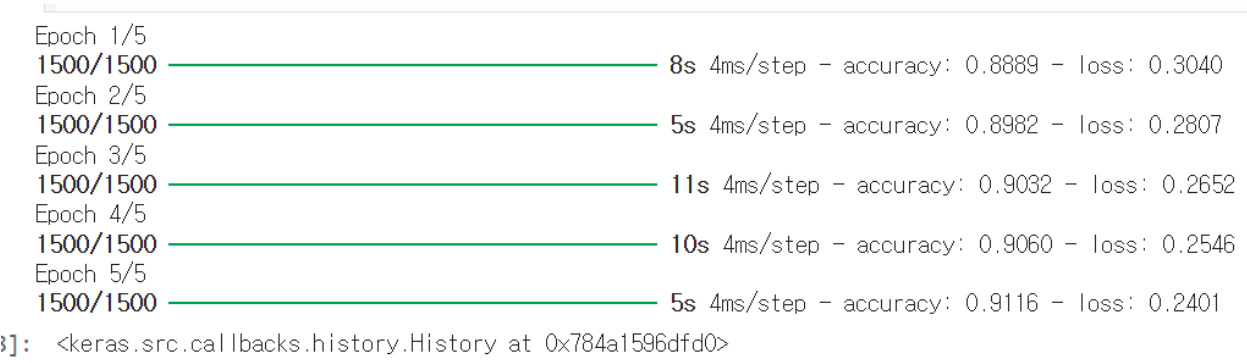

In [3]:
import tensorflow as tf

# 같은 코드라면 매번 같은 결과가 나오도록 "랜덤 고정"
# (실험할 때 결과가 흔들리지 않게 해주는 안전핀)
tf.keras.utils.set_random_seed(42)

# 연산을 최대한 "항상 똑같은 방식"으로 수행하도록 설정
# (같은 입력이면 같은 출력이 나오도록 더 단단히 고정)
tf.config.experimental.enable_op_determinism()

from tensorflow import keras
from sklearn.model_selection import train_test_split

# 패션 MNIST 데이터 불러오기
# train_input : (60000, 28, 28) 이미지
# train_target: (60000,) 정답 라벨(0~9)
# test_input  : (10000, 28, 28) 이미지
# test_target : (10000,) 정답 라벨(0~9)
(train_input, train_target), (test_input, test_target) = \
    keras.datasets.fashion_mnist.load_data()

# 픽셀 값(0~255)을 0~1 범위로 바꿔서 학습이 안정적으로 되게 만들기
# (원래는 진하게/연하게를 0~255로 표현했는데, 0~1로 "단위"를 맞춰주는 느낌)
train_scaled = train_input / 255.0

# 훈련 데이터 중 20%를 떼어서 검증 데이터로 사용
# train_test_split은 섞어서(split) 나누어 주는데,
# random_state를 고정하면 매번 같은 방식으로 나뉜다.
train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42
)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
print("훈련데이터 :")
print(train_scaled.shape, train_target.shape)
print("테스트데이터 :")
print(test_input.shape, test_target.shape)
print("검증데이터 :")
print(val_scaled.shape, val_target.shape)

훈련데이터 :
(48000, 28, 28) (48000,)
테스트데이터 :
(10000, 28, 28) (10000,)
검증데이터 :
(12000, 28, 28) (12000,)


In [5]:
# 모델을 생성하는 함수
# a_layer 매개변수로 "추가 층"을 전달할 수 있음
def model_fn(a_layer=None):

    # 순차적으로 층을 쌓는 Sequential 모델 생성
    model = keras.Sequential()

    # 28x28 이미지 데이터를 1차원 벡터(784개)로 펼치는 층
    # 신경망의 Dense 층은 1차원 입력을 사용하기 때문에 필요함
    model.add(keras.layers.Flatten(input_shape=(28, 28)))

    # 은닉층(hidden layer)
    # 뉴런 100개를 사용하고 활성화 함수는 ReLU
    # 입력 특징을 조합해서 의미있는 패턴을 학습하는 역할
    model.add(keras.layers.Dense(100, activation='relu'))

    # 만약 a_layer가 전달되면
    # 은닉층 뒤에 그 층을 추가로 붙인다
    # (예: Dropout 같은 층을 실험할 때 사용)
    if a_layer:
        model.add(a_layer)

    # 출력층(output layer)
    # 패션 MNIST는 10개의 클래스이므로 뉴런 10개 사용
    # softmax를 사용하여 각 클래스의 확률을 계산
    model.add(keras.layers.Dense(10, activation='softmax'))

    # 완성된 모델 반환
    return model

In [6]:
# model_fn() 함수를 호출하여 신경망 모델을 생성
# 매개변수를 넣지 않았기 때문에 기본 구조의 모델이 만들어진다.
# (Flatten → Dense(100) → Dense(10))
model = model_fn()

# model.summary()는 만들어진 신경망의 구조를 보여준다.
# 각 층(layer)의 이름, 출력 크기(shape), 파라미터 개수 등을 확인할 수 있다.
# 즉, 모델이 어떤 구조로 만들어졌는지 "설계도"를 출력하는 기능이다.
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])
#                   다중분류                                    정확도

In [8]:
# 모델을 학습시키고 학습 기록을 history 변수에 저장
# fit()은 모델이 훈련 데이터를 보면서 가중치를 계속 수정하는 과정이다.
history = model.fit(train_scaled, train_target, epochs=5, verbose=2)

# train_scaled : 학습에 사용할 입력 데이터 (이미지)
# train_target : 각 이미지의 정답 라벨

# epochs=5
# 전체 훈련 데이터를 5번 반복해서 학습한다는 의미
# 한 번 전체 데이터를 학습하는 것을 "1 에포크"라고 부른다.

# verbose는 학습 진행 상황을 얼마나 자세히 출력할지 결정하는 옵션이다.

# verbose=0
# 학습 과정 출력 없음 (조용히 학습)

# verbose=1
# 기본값
# 진행 막대(progress bar)와 함께 손실(loss), 정확도 등이 출력됨

# verbose=2
# 진행 막대는 생략하고
# 에포크마다 결과만 간단히 한 줄씩 출력

Epoch 1/5
1500/1500 - 7s - 5ms/step - accuracy: 0.8112 - loss: 0.5311
Epoch 2/5
1500/1500 - 5s - 3ms/step - accuracy: 0.8586 - loss: 0.3903
Epoch 3/5
1500/1500 - 4s - 3ms/step - accuracy: 0.8729 - loss: 0.3523
Epoch 4/5
1500/1500 - 5s - 4ms/step - accuracy: 0.8810 - loss: 0.3306
Epoch 5/5
1500/1500 - 4s - 3ms/step - accuracy: 0.8873 - loss: 0.3141


In [9]:
print(history)  # 위에 fit한 결과를 History객체가 가지고 있는데 이것을 history 변수에 담음

In [10]:
# history 객체 안에 저장된 "학습 기록의 종류"를 확인
# history.history는 딕셔너리(dictionary) 형태로 저장되어 있다.
# keys()를 사용하면 어떤 값들이 기록되어 있는지 확인할 수 있다.
print(history.history.keys())

# history.history 안에는 학습 과정에서 측정된 값들이 저장된다.
# 예를 들면 다음과 같은 정보가 들어있다.
# loss      : 모델이 얼마나 틀렸는지를 나타내는 값
# accuracy  : 모델이 얼마나 정답을 맞췄는지를 나타내는 값

# accuracy 값이 history에 포함되는 이유는
# 모델을 compile() 할 때 metrics=['accuracy'] 를 지정했기 때문이다.
# compile 단계에서 "학습 중에 accuracy도 측정하라"고 설정했기 때문에
# 학습 기록(history)에 accuracy가 함께 저장된다.

dict_keys(['accuracy', 'loss'])


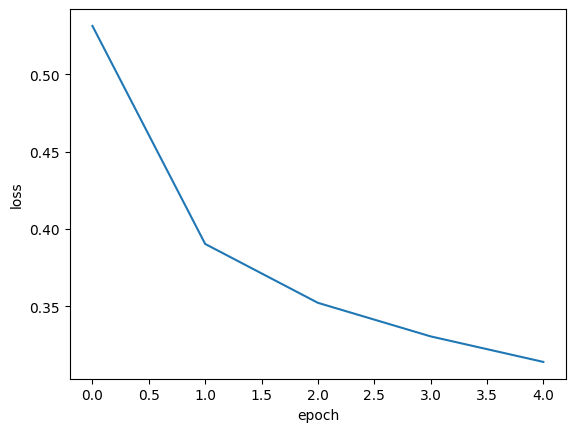

In [11]:
import matplotlib.pyplot as plt

# history.history['loss']에는
# 각 에포크(epoch)마다 계산된 손실(loss) 값이
# 리스트 형태로 저장되어 있다.
# 예: [0.65, 0.48, 0.36, 0.29, 0.24]

# plt.plot()을 사용하여 에포크별 손실 값을 그래프로 그림
# 즉, 학습이 진행되면서 모델이 얼마나 덜 틀리게 되었는지 확인할 수 있다.
plt.plot(history.history['loss'])

# x축 이름 설정
# x축은 에포크(epoch) 번호를 의미한다.
plt.xlabel('epoch')

# 파이썬 리스트 인덱스는 0부터 시작하기 때문에
# epochs=5로 학습했다면 x축은 0,1,2,3,4 로 표시된다.

# y축 이름 설정
# y축은 손실(loss) 값으로
# 모델이 얼마나 틀렸는지를 나타낸다.
plt.ylabel('loss')

# 그래프 화면에 출력
plt.show()

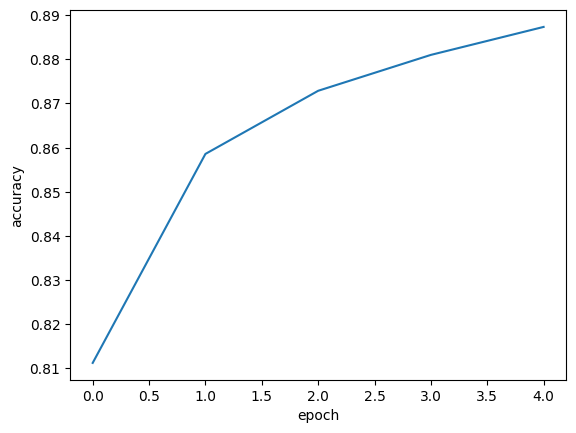

In [12]:
# 이번에는 정확도를 출력
plt.plot(history.history['accuracy'])
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()

# 결과분석 : 에포크마다 손실이 감소하고 정확도가 향상함

In [13]:
# 이번에는 학습 반복 횟수(에포크)를 20번으로 늘려서 학습해 본다.

# model_fn() 함수를 사용하여 신경망 모델을 생성
# 기본 구조 : Flatten(입력층) → Dense(은닉층) → Dense(출력층)
model = model_fn()

# 모델을 학습할 준비를 하는 단계 (컴파일)
# loss : 모델이 얼마나 틀렸는지 계산하는 방법
# sparse_categorical_crossentropy :
# 정답이 정수 라벨(0~9)인 다중 분류 문제에서 사용하는 손실 함수
# metrics=['accuracy'] :
# 학습 과정에서 정확도도 함께 측정하도록 설정
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 모델 학습 시작
# train_scaled : 학습에 사용할 이미지 데이터
# train_target : 각 이미지의 정답 라벨
# epochs=20 : 전체 훈련 데이터를 20번 반복 학습
# verbose=0 : 학습 진행 과정을 화면에 출력하지 않음
history = model.fit(train_scaled, train_target, epochs=20, verbose=0)

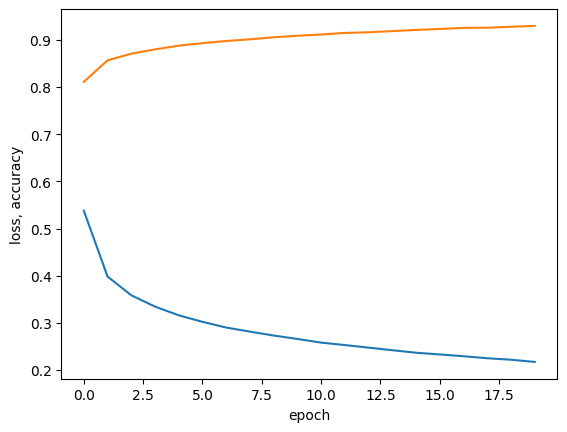

In [14]:
plt.plot(history.history['loss'])   # 손실율
plt.plot(history.history['accuracy']) # 정확도
plt.xlabel('epoch')
plt.ylabel('loss, accuracy')
plt.show()

In [15]:
# 모델이 학습되는 동안 "검증 데이터의 손실"도 함께 확인할 수 있다.
# validation_data=(val_scaled, val_target) 옵션을 사용하면
# 에포크마다 검증 데이터의 성능도 같이 계산된다.

# 이전에 배운 확률적 경사 하강법(SGD)에서는
# 에포크 횟수에 따라 과소적합(underfitting)과 과대적합(overfitting)이 발생할 수 있었다.

# 인공신경망 역시 가중치를 업데이트할 때
# 경사 하강법(gradient descent)을 사용하기 때문에
# 에포크와 과적합의 관계가 동일하게 나타난다.

# 따라서 모델이 잘 학습되고 있는지 확인하려면
# 다음 두 가지 정보를 함께 비교해야 한다.
# 1) 훈련 데이터의 손실(loss)
# 2) 검증 데이터의 손실(val_loss)

# 만약 훈련 손실만 보면
# 모델이 실제로 잘 학습되는지 판단하기 어렵다.

# 예를 들어
# 훈련 데이터에서는 손실이 계속 줄어들지만
# 검증 데이터에서는 손실이 증가한다면
# 이는 과대적합(overfitting)이 발생했다는 신호이다.

# 그래서 인공신경망에서는
# 훈련 손실과 검증 손실을 함께 그래프로 확인하는 것이 중요하다.

# 추가로 "정확도(accuracy)" 대신 "손실(loss)"을 더 중요하게 보는 이유는
# 모델이 실제로 최적화하는 대상이 손실 함수이기 때문이다.

# 신경망은 학습 과정에서
# 정확도를 직접 높이도록 학습하는 것이 아니라
# 손실(loss)을 최소화하도록 가중치를 조정한다.

# 따라서 손실 값이 줄어드는지를 확인하는 것이
# 모델이 제대로 학습되고 있는지 판단하는 더 좋은 기준이 된다.

In [16]:
model = model_fn()
model.summary()
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(train_scaled, train_target, epochs=20, verbose=1,
                    validation_data=(val_scaled, val_target))
#                   검증손실을 구하기위한 매개값 추가 됨 3분걸림

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7609 - loss: 0.6817 - val_accuracy: 0.8484 - val_loss: 0.4271
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8512 - loss: 0.4081 - val_accuracy: 0.8586 - val_loss: 0.3910
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8686 - loss: 0.3628 - val_accuracy: 0.8598 - val_loss: 0.3859
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8755 - loss: 0.3391 - val_accuracy: 0.8621 - val_loss: 0.3755
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8849 - loss: 0.3211 - val_accuracy: 0.8603 - val_loss: 0.3916
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8915 - loss: 0.3082 - val_accuracy: 0.8658 - val_loss: 0.3957
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8952 - loss: 0.2964 - val_accuracy: 0.8652 - val_loss: 0.3949
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8999 - loss: 0.2868 - 

In [17]:
print(history.history.keys())
# 정확도accuracy, 손실loss 값이 있다.
# 추가로 검증세트 정확도 val_accuracy, 검증세트 손실 val_loss가 나옴

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


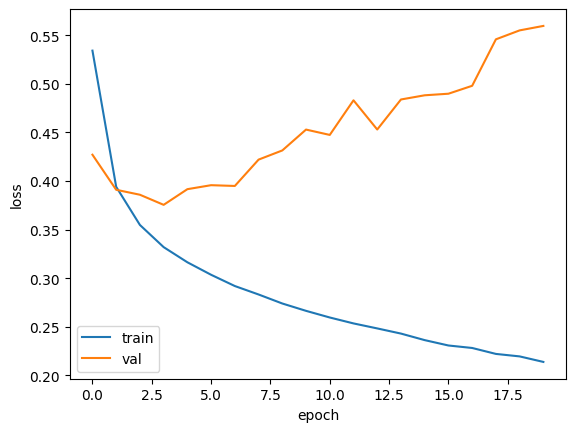

In [18]:
# 과대적합(overfitting)이나 과소적합(underfitting)을 확인하기 위해
# 훈련 데이터의 손실(train loss)과 검증 데이터의 손실(val loss)을
# 하나의 그래프에 함께 그려서 비교한다.

# 훈련 데이터에서 계산된 손실값
# 에포크가 진행될수록 모델이 훈련 데이터를 얼마나 잘 맞추는지 확인할 수 있다.
plt.plot(history.history['loss'])

# 검증 데이터에서 계산된 손실값
# 모델이 새로운 데이터에도 잘 동작하는지 확인하기 위한 지표
plt.plot(history.history['val_loss'])

# x축은 학습 반복 횟수(에포크)
plt.xlabel('epoch')

# y축은 손실값(loss)
# 값이 작을수록 모델이 정답에 가까운 예측을 한다는 의미
plt.ylabel('loss')

# 그래프의 선이 무엇을 의미하는지 표시
# train : 훈련 데이터 손실
# val   : 검증 데이터 손실
plt.legend(['train', 'val'])

# 그래프 출력
plt.show()


# 결과 분석
# 초기에는 훈련 손실과 검증 손실이 모두 감소한다.
# 하지만 약 5번째 에포크 이후부터 검증 손실이 다시 증가하기 시작한다.

# 반면 훈련 손실은 계속 감소한다.
# 이는 모델이 훈련 데이터에만 점점 더 맞춰지고 있다는 의미이며
# 과대적합(overfitting)이 발생했음을 나타낸다.

# 따라서 검증 손실이 증가하기 시작하는 시점을
# 가능한 뒤로 늦추면 모델의 일반화 성능이 좋아질 가능성이 있다.

# 과대적합을 줄이는 방법으로는
# 이전에 사용했던 규제 방식 외에도
# 신경망에서 자주 사용하는 규제 방법인 Dropout을 사용할 수 있다.
# Dropout은 학습 과정에서 일부 뉴런을 무작위로 비활성화하여
# 모델이 특정 패턴에 과하게 의존하는 것을 방지한다.

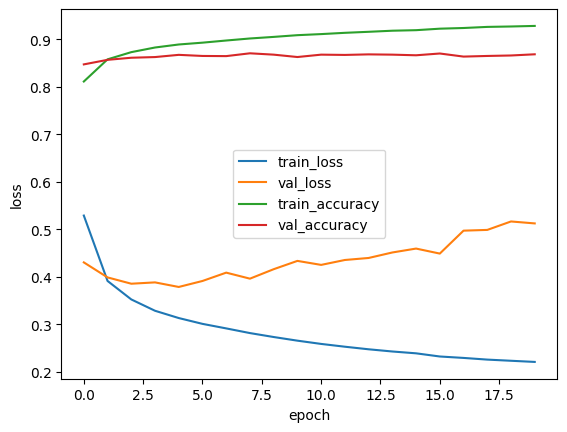

In [19]:
# 이번에는 옵티마이저(optimizer)를 변경하여
# 과대적합이 완화되는지 확인해 본다.

# RMSprop 옵티마이저는 신경망 학습에서 자주 사용되는 방법으로
# 학습 속도와 안정성 측면에서 많은 문제에서 잘 동작한다.
# 대표적인 옵티마이저로는 RMSprop 외에도 Adagrad, Adam 등이 있다.

# 이전에 만든 모델 생성 함수로 모델을 새로 만든다.
model = model_fn()

# 모델 학습 설정(컴파일)
# optimizer : 가중치를 업데이트하는 방법
# loss : 모델이 얼마나 틀렸는지 계산하는 방법
# metrics : 학습 중에 함께 확인할 성능 지표
model.compile(optimizer='RMSprop',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 모델 학습 시작
# epochs=20 : 전체 데이터를 20번 반복 학습
# verbose=0 : 학습 진행 과정은 출력하지 않음
# validation_data : 에포크마다 검증 데이터 성능도 함께 계산
history = model.fit(train_scaled, train_target,
                    epochs=20,
                    verbose=0,
                    validation_data=(val_scaled, val_target))


# 훈련 데이터의 손실값 그래프
plt.plot(history.history['loss'])

# 검증 데이터의 손실값 그래프
plt.plot(history.history['val_loss'])

# 훈련 데이터 정확도 그래프
plt.plot(history.history['accuracy'])

# 검증 데이터 정확도 그래프
plt.plot(history.history['val_accuracy'])

# x축 : 에포크(학습 반복 횟수)
plt.xlabel('epoch')

# y축 : 손실 또는 정확도 값
plt.ylabel('loss')

# 그래프 범례 표시
plt.legend(['train_loss', 'val_loss', 'train_accuracy', 'val_accuracy'])

# 그래프 출력
plt.show()

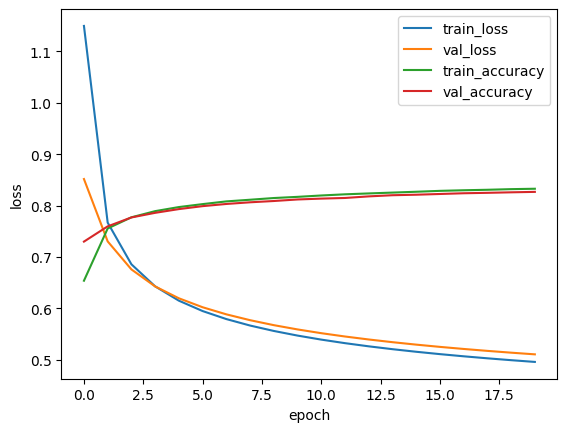

In [20]:
# 모델 생성 (이전에 만든 model_fn 함수 사용)
model = model_fn()

# Adagrad 옵티마이저 생성
# Adagrad는 학습 과정에서 각 파라미터마다 학습률을 자동으로 조절하는 최적화 방법
# 자주 업데이트되는 파라미터는 학습률을 줄이고
# 드물게 업데이트되는 파라미터는 학습률을 크게 유지하는 특징이 있다.
adagrad = keras.optimizers.Adagrad()

# 모델 컴파일
# optimizer : 가중치를 업데이트하는 방법 (여기서는 Adagrad 사용)
# loss : 다중 분류 문제에서 사용하는 손실 함수
# metrics : 학습 과정에서 정확도도 함께 측정
model.compile(optimizer=adagrad,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 모델 학습
# epochs=20 : 전체 훈련 데이터를 20번 반복 학습
# verbose=0 : 학습 과정 출력 없이 조용히 학습
# validation_data : 에포크마다 검증 데이터 성능도 함께 계산
history = model.fit(train_scaled, train_target,
                    epochs=20,
                    verbose=0,
                    validation_data=(val_scaled, val_target))

# 훈련 데이터 손실 그래프
plt.plot(history.history['loss'])

# 검증 데이터 손실 그래프
plt.plot(history.history['val_loss'])

# 훈련 데이터 정확도 그래프
plt.plot(history.history['accuracy'])

# 검증 데이터 정확도 그래프
plt.plot(history.history['val_accuracy'])

# x축 : 에포크(학습 반복 횟수)
plt.xlabel('epoch')

# y축 : 손실 또는 정확도 값
plt.ylabel('loss')

# 그래프 범례 표시
plt.legend(['train_loss', 'val_loss', 'train_accuracy', 'val_accuracy'])

# 그래프 출력
plt.show()

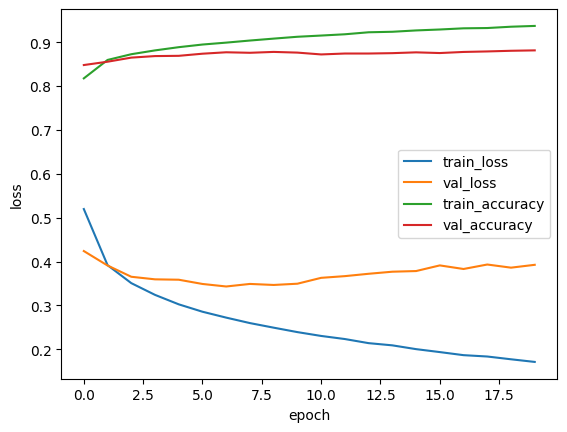

In [21]:
# 모델 생성 (이전에 정의한 model_fn 함수 사용)
model = model_fn()

# 모델 학습 설정
# optimizer='adam' :
# Adam 옵티마이저 사용 (현재 딥러닝에서 가장 많이 사용되는 최적화 방법 중 하나)
# RMSprop과 Momentum 개념을 결합한 방식으로
# 학습 속도와 안정성이 좋은 편이다.
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 모델 학습
# epochs=20 : 전체 훈련 데이터를 20번 반복 학습
# verbose=0 : 학습 진행 상황 출력하지 않음
# validation_data : 매 에포크마다 검증 데이터 성능을 함께 계산
history = model.fit(train_scaled, train_target,
                    epochs=20,
                    verbose=0,
                    validation_data=(val_scaled, val_target))  # 약 2분 25초 소요

# 훈련 데이터 손실값 그래프
plt.plot(history.history['loss'])

# 검증 데이터 손실값 그래프
plt.plot(history.history['val_loss'])

# 훈련 데이터 정확도 그래프
plt.plot(history.history['accuracy'])

# 검증 데이터 정확도 그래프
plt.plot(history.history['val_accuracy'])

# x축 : 학습 반복 횟수(epoch)
plt.xlabel('epoch')

# y축 : 손실값 또는 정확도 값
plt.ylabel('loss')

# 그래프 범례
plt.legend(['train_loss', 'val_loss', 'train_accuracy', 'val_accuracy'])

# 그래프 출력
plt.show()

# 결과 해석
# 여러 옵티마이저(RMSprop, Adagrad, Adam)를 비교해보면
# Adam 옵티마이저가 가장 안정적으로 학습되는 모습을 보인다.

# 하지만 훈련 손실과 검증 손실 그래프를 보면
# 여전히 과대적합(overfitting)이 발생할 가능성이 있다.

# 따라서 이후에는 과대적합을 줄이기 위해
# 신경망에서 자주 사용하는 규제 방법인 Dropout 등을 적용해 볼 수 있다.

In [ ]:
# Dropout은 딥러닝 분야의 연구자인 제프리 힌턴(Geoffrey Hinton)이 제안한 기법이다.
# 신경망 학습 과정에서 일부 뉴런을 무작위로 비활성화하여 과대적합(overfitting)을 줄이는 방법이다.

# 학습 과정에서 특정 뉴런의 출력을 랜덤하게 0으로 만들어
# 해당 뉴런이 계산에 참여하지 않도록 한다.

# 예를 들어 어떤 데이터를 처리할 때
# 은닉층의 두 번째 뉴런이 드롭아웃되면 h2의 출력이 사라진다.

# 다른 데이터를 처리할 때는
# 은닉층의 첫 번째 뉴런이 드롭아웃될 수도 있다.

# 즉, 매번 학습할 때마다
# 어떤 뉴런이 꺼질지 랜덤하게 결정된다.

# 또한 "얼마나 많은 뉴런을 끌 것인지"는
# Dropout 비율이라는 하이퍼파라미터로 우리가 직접 설정할 수 있다.

# Dropout이 과대적합을 줄이는 이유는
# 특정 뉴런 하나에 지나치게 의존하는 것을 막기 때문이다.

# 일부 뉴런이 항상 사용되지 않을 수 있기 때문에
# 신경망은 다양한 뉴런을 활용해서 학습해야 한다.

# 그 결과 모델이 특정 패턴에만 맞춰지는 것을 방지하고
# 더 일반화된(안정적인) 예측을 만들 수 있게 된다.

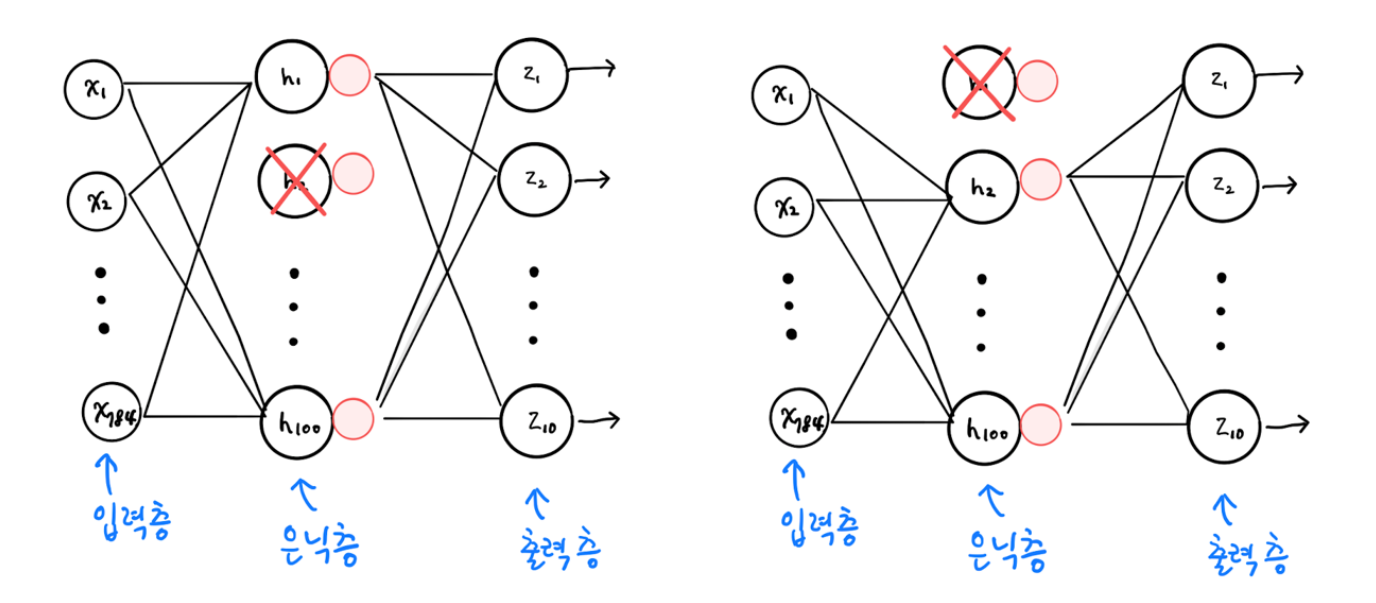

In [22]:
# 드롭아웃을 적용한 신경망을 보면
# 마치 여러 개의 신경망을 동시에 학습시키는 것처럼 생각할 수 있다.

# 왜냐하면 학습할 때마다 랜덤하게 다른 뉴런들이 꺼지기 때문에
# 매번 조금씩 다른 구조의 신경망이 만들어지기 때문이다.

# 이런 방식은 여러 개의 모델을 함께 사용하는
# "앙상블(Ensemble)" 방법과 비슷한 효과를 낸다.

# 앙상블은 여러 모델의 예측을 결합하여
# 더 안정적이고 좋은 예측을 만드는 머신러닝 기법이다.
# 또한 과대적합(overfitting)을 줄이는 데 도움이 된다.


# 케라스에서는 Dropout 층을 keras.layers.Dropout 으로 제공한다.
# 특정 층 뒤에 Dropout을 추가하면
# 그 층의 일부 뉴런 출력을 랜덤하게 0으로 만든다.

# Dropout은 층(layer)처럼 사용되지만
# 학습되는 가중치(weight)나 bias 같은 파라미터는 존재하지 않는다.


# model_fn 함수에 Dropout 층을 전달하여
# 은닉층 뒤에 Dropout 층을 추가한다.
# Dropout(0.3)은 전체 뉴런 중 약 30%를 랜덤하게 비활성화한다.
model = model_fn(keras.layers.Dropout(0.3))


# 모델 구조 요약 확인
model.summary()

# Dropout 층은 학습되는 파라미터가 없기 때문에
# summary에서 Param # 값이 0으로 표시된다.

# 또한 Dropout은 뉴런 일부를 0으로 만들 뿐
# 출력 데이터의 전체 크기(shape)는 변경하지 않는다.
# 즉 입력 크기와 출력 크기가 동일하게 유지된다.

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_6 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

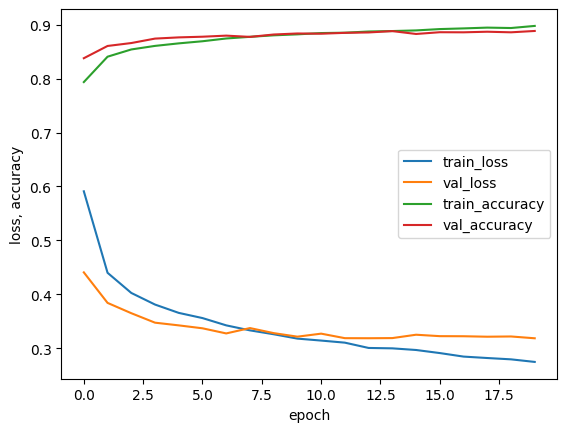

In [23]:
# 주의사항 : Dropout은 "훈련할 때만" 적용된다.
# 모델 평가(evaluate)나 예측(predict)을 할 때는 Dropout을 사용하지 않는다.

# 이유는 간단하다.
# 예측을 할 때는 학습된 모든 뉴런을 사용해야
# 가장 정확한 결과를 얻을 수 있기 때문이다.

# 텐서플로와 케라스에서는
# 모델이 학습(fit) 상태일 때만 Dropout을 적용하고
# 평가나 예측을 할 때는 자동으로 Dropout을 비활성화한다.


# 모델 컴파일
# optimizer : Adam 사용
# loss : 다중 분류 문제에서 사용하는 손실 함수
# metrics : 학습 중 정확도도 함께 계산
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


# 모델 학습
# epochs=20 : 전체 데이터를 20번 반복 학습
# validation_data : 매 에포크마다 검증 데이터 성능 계산
history = model.fit(train_scaled, train_target,
                    epochs=20,
                    verbose=0,
                    validation_data=(val_scaled, val_target))


# 훈련 데이터 손실 그래프
plt.plot(history.history['loss'])

# 검증 데이터 손실 그래프
plt.plot(history.history['val_loss'])

# 훈련 데이터 정확도 그래프
plt.plot(history.history['accuracy'])

# 검증 데이터 정확도 그래프
plt.plot(history.history['val_accuracy'])

# x축 : 학습 반복 횟수(epoch)
plt.xlabel('epoch')

# y축 : 손실값(loss)과 정확도(accuracy)
plt.ylabel('loss, accuracy')

# 그래프 범례 표시
plt.legend(['train_loss', 'val_loss', 'train_accuracy', 'val_accuracy'])

# 그래프 출력
plt.show()


# 결과 해석
# Dropout을 적용한 결과 이전보다 과대적합이 확실히 줄어든 것을 볼 수 있다.

# 약 10번째 에포크까지는 검증 손실이 감소하지만
# 그 이후에는 감소가 멈추고 조금씩 증가하기 시작한다.

# 즉, 20번까지 학습하면 다시 과대적합이 발생할 가능성이 있다.

# 따라서 검증 손실이 가장 낮은 시점(약 10 epoch)에서
# 학습을 멈추는 것이 더 좋은 모델이 될 수 있다.

# 이런 방법을 "조기 종료(Early Stopping)"라고 하며
# 다음 단계에서 적용해 볼 수 있다.

In [24]:
# 나중에 모델을 다시 사용하기 위해
# 학습된 모델을 파일로 저장하는 방법을 알아본다.

# Dropout이 포함된 모델 생성
model = model_fn(keras.layers.Dropout(0.3))

# 모델 학습 설정
# optimizer : Adam 사용
# loss : 다중 분류 문제에서 사용하는 손실 함수
# metrics : 학습 중 정확도도 함께 확인
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 모델 학습
# epochs=10 : 전체 데이터를 10번 반복 학습
# validation_data : 매 에포크마다 검증 데이터 성능 확인
history = model.fit(train_scaled, train_target,
                    epochs=10,
                    verbose=0,
                    validation_data=(val_scaled, val_target))


# 모델 전체 저장
# 모델 구조 + 가중치 + 학습 설정(optimizer 등)이 모두 저장된다.
# 나중에 이 파일 하나만 있으면 동일한 모델을 바로 복원할 수 있다.
model.save('model-whole-ep10.keras')


# 케라스에는 가중치(weight)만 저장하는 save_weights() 메서드도 있다.
# 이 경우 모델 구조는 저장되지 않고
# 학습된 파라미터(weight, bias)만 저장된다.

# TensorFlow의 체크포인트 형식이나
# HDF5(.h5) 형식으로 저장할 수 있다.

# 아래 코드는 HDF5 형식으로 가중치만 저장하는 예이다.
model.save_weights('model-ep10.weights.h5')

In [ ]:
# 딥러닝 모델을 저장하는 방법에는 크게 두 가지가 있다.

# 1️⃣ model.save("model.keras")
# 모델 전체를 저장하는 방법

# 저장되는 내용
# - 모델 구조 (Layer 구성)
# - 학습된 가중치(weights)
# - 옵티마이저 상태
# - compile 정보 (loss, metrics 등)

# 즉, 모델을 구성하는 모든 정보가 함께 저장된다.
# 그래서 나중에 코드 없이도 동일한 모델을 바로 복원할 수 있다.

# 모델 불러오기 예
# model = load_model("model.keras")

# 이런 방식은
# 모델을 배포하거나 실제 예측 시스템에서 사용할 때 많이 사용된다.



# 2️⃣ model.save_weights("model_weights.h5")
# 모델의 가중치(weight)만 저장하는 방법

# 저장되는 내용
# - 학습된 가중치(weight, bias)

# 저장되지 않는 내용
# - 모델 구조
# - optimizer 상태
# - compile 정보

# 따라서 가중치만 저장한 경우
# 같은 구조의 모델을 먼저 다시 만들어야 한다.

# 예시
# model = create_model()     # 동일한 모델 구조 다시 생성
# model.load_weights("model_weights.h5")

# 이런 방식은
# 모델을 실험하는 과정에서 중간 결과를 저장할 때 자주 사용된다.



# 중요한 개념
# 모델은 훈련 데이터를 그대로 저장하지 않는다.

# 모델이 학습을 통해 저장하는 것은
# 데이터 자체가 아니라 "패턴 정보"이다.

# 예를 들어 생선 무게를 예측하는 모델이 있다면

# 입력 데이터
# 길이, 높이, 두께 → 생선 무게

# 학습 과정에서 모델이 찾는 것은
# 입력과 출력 사이의 관계(패턴)이다.

# 그래서 훈련이 끝난 후 모델에 저장되는 것은
# 다음과 같은 값들이다.

# weight1 = 0.23
# weight2 = 1.52
# bias = -0.77

# 정리
# 데이터 → 학습 → 가중치(weight)가 업데이트됨
# 모델은 데이터를 기억하는 것이 아니라
# 데이터의 패턴을 가중치 형태로 저장한다.

In [25]:
# Keras 모델을 model.save("model.keras") 로 저장하면
# 하나의 .keras 파일이 생성된다.

# 이 파일은 실제로 "압축(zip) 파일" 형태이며
# 내부에는 모델을 복원하기 위한 여러 파일이 들어 있다.

# 예를 들어 다음 코드로 내부 파일을 확인할 수 있다.
# with zipfile.ZipFile("model.keras", 'r') as z:
#     print(z.namelist())

# 출력 예
# ['config.json', 'metadata.json', 'model.weights.h5']

# model.keras
# ├ config.json        : 모델 구조 정보
# ├ metadata.json      : 케라스 버전 등 환경 정보
# └ model.weights.h5   : 학습된 가중치 값


# ------------------------------------------------------------
# config.json
# ------------------------------------------------------------
# 모델의 구조(layer 구성)가 저장되는 파일이다.
# 즉, 어떤 층이 있고 어떤 활성화 함수가 사용되었는지 기록되어 있다.

# 예시
# {
#   "class_name": "Sequential",
#   "config": {
#     "layers": [
#       {
#         "class_name": "Dense",
#         "config": {
#           "units": 64,
#           "activation": "relu"
#         }
#       }
#     ]
#   }
# }

# 위 내용은 다음과 같은 정보를 의미한다.
# - Sequential 모델 사용
# - Dense 층 존재
# - 뉴런 개수 64개
# - 활성화 함수 ReLU


# ------------------------------------------------------------
# model.weights.h5
# ------------------------------------------------------------
# 학습된 가중치(weight)와 bias 값이 저장되는 파일이다.

# 예시
# dense/kernel:0
# dense/bias:0
# dense_1/kernel:0
# dense_1/bias:0

# 실제 값 예
#  0.2312
# -0.7811
#  0.5321

# 즉 모델이 학습하면서 찾은 "패턴 정보"가
# 숫자 형태로 저장된다.


# ------------------------------------------------------------
# metadata.json
# ------------------------------------------------------------
# 모델이 어떤 환경에서 만들어졌는지에 대한 정보가 저장된다.

# 예시
# {
#   "keras_version": "3.0",
#   "backend": "tensorflow"
# }

# 이 정보는 모델을 불러올 때
# 같은 환경에서 제대로 동작하도록 도와준다.

In [26]:
# 이제는 저장한 모델을 불려와 테스트를 진행 해보자
!ls -al model*

-rw-r--r-- 1 root root 976600 Mar  5 02:57 model-ep10.weights.h5
-rw-r--r-- 1 root root 979409 Mar  5 02:57 model-whole-ep10.keras


In [27]:
# 실험 1
# 새로 만든 모델에 이전에 저장했던 "가중치(weight)"를 불러와서 사용해 본다.


# model_fn()을 사용해 동일한 구조의 모델을 다시 생성
# 이 모델은 아직 학습되지 않은 상태이다.
model = model_fn(keras.layers.Dropout(0.3))


# 이전에 저장했던 가중치 파일을 불러온다.
# model-ep10.weights.h5 파일에는 학습된 weight와 bias 값만 저장되어 있다.
model.load_weights('model-ep10.weights.h5')


# load_weights()는 save_weights()와 짝을 이루는 메서드이다.
# 즉 save_weights()로 저장한 가중치를 다시 모델에 적용할 때 사용한다.


# 중요한 주의사항
# load_weights()를 사용할 때는
# 가중치를 저장했던 모델과 "완전히 동일한 구조"의 모델이어야 한다.

# 예를 들어
# 층 개수
# 뉴런 개수
# Dropout 위치

# 이런 구조가 하나라도 다르면
# 가중치를 정상적으로 불러올 수 없다.


# 모델 구조 확인
# Dropout 층이 포함된 동일한 구조의 모델이 만들어졌는지 확인할 수 있다.
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_8 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
# 모델의 검증 데이터 정확도를 직접 계산해 보자.
import numpy as np

# predict() 메서드는 각 샘플에 대해
# "각 클래스에 속할 확률"을 반환한다.
# 패션 MNIST는 10개의 클래스가 있기 때문에
# 각 샘플마다 10개의 확률값이 나온다.

# 검증 데이터는 12,000개의 이미지가 있으므로
# predict() 결과의 형태(shape)는 (12000, 10)이 된다.
# 즉, 12000개의 샘플 × 10개의 클래스 확률

# 각 샘플에서 가장 확률이 높은 클래스의 인덱스를 선택
# argmax()는 가장 큰 값의 "위치(index)"를 반환한다.
val_labels = np.argmax(model.predict(val_scaled), axis=-1)


# axis=-1 은 배열의 "마지막 차원"을 기준으로 계산한다는 의미이다.
# 현재 predict 결과가 (12000, 10)이므로
# 마지막 차원(10개 클래스)에서 가장 큰 값을 찾게 된다.

# 결과적으로 val_labels의 shape는 (12000,)
# 즉 각 이미지에 대한 "예측 클래스 번호"가 저장된다.


# 예측 결과(val_labels)와 실제 정답(val_target)을 비교
# 같으면 True, 다르면 False가 된다.
# True는 1, False는 0으로 계산되기 때문에
# 평균을 구하면 정확도가 된다.
print(np.mean(val_labels == val_target))  # 예: 0.8796 → 약 87.96% 정확도


# 참고 : axis 개념 정리

# axis=1
# 각 행(row)에서 가장 큰 값의 인덱스를 선택
# 즉 "한 샘플의 여러 클래스 중 최고 확률" 선택

# axis=0
# 각 열(column)에서 가장 큰 값의 인덱스를 선택
# 보통 이런 분류 문제에서는 사용하지 않는다.

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
0.8805833333333334


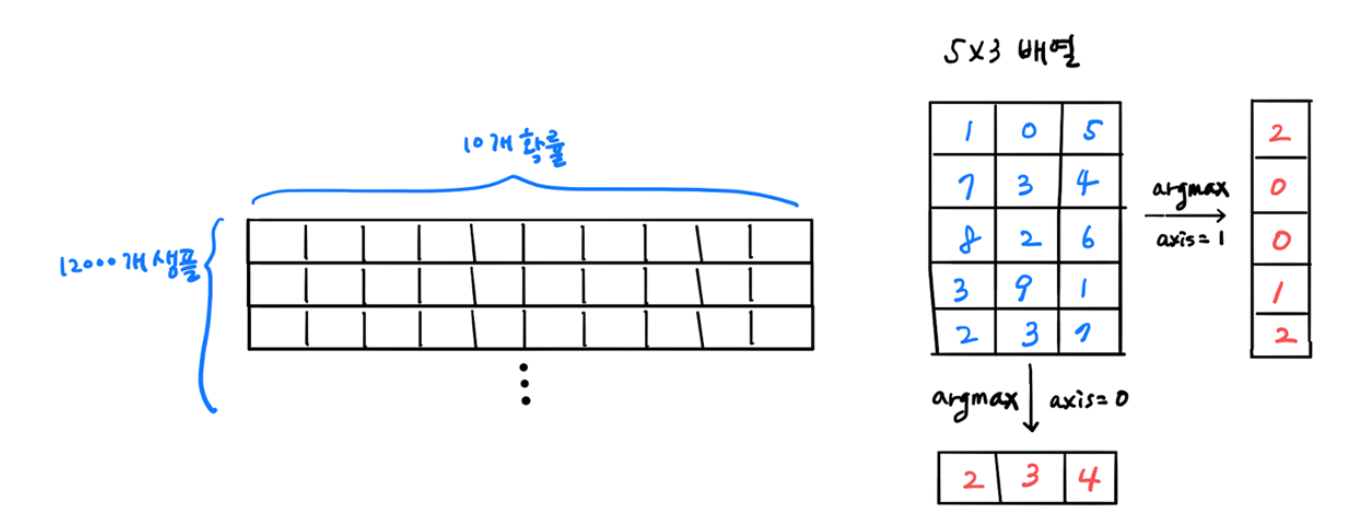

In [29]:
# 저장해 둔 "전체 모델 파일(.keras)"을 불러온 뒤
# 검증 세트(val)에서 성능(손실, 정확도)을 다시 확인한다.

# load_model()은 model.save()로 저장한 파일을 읽어
# 모델 구조 + 가중치 + (저장되어 있다면) 컴파일/옵티마이저 상태까지 함께 복원한다.
model = keras.models.load_model('model-whole-ep10.keras')

# evaluate()는 주어진 데이터에서 모델의 성능을 계산한다.
# compile에서 설정한 loss와 metrics(accuracy 등)에 따라 결과가 출력된다.
# 같은 epoch(10)에서 저장한 동일 모델을 불러왔기 때문에
# 이전에 계산했던 검증 정확도와 거의 동일한 값이 나온다.
model.evaluate(val_scaled, val_target)


# 현 상태 정리(분석 메모)
# - epochs=20으로 학습해보면, 어느 지점부터 검증 성능이 더 이상 좋아지지 않거나 나빠질 수 있다.
# - 그래서 과대적합이 시작되기 전(검증 성능이 가장 좋을 때)의 epoch까지만 학습한 모델(예: ep10)을 저장해 둔 것.

# 목표
# - 매번 "20까지 학습 → 그래프 확인 → 다시 10으로 재학습"처럼 두 번 학습하지 않고
# - 한 번의 학습으로 끝내고 싶다.

# 해결 아이디어
# - 케라스 콜백(callback)을 사용한다.
#   예) EarlyStopping: 검증 성능이 좋아지지 않으면 자동으로 학습을 멈춤
#   예) ModelCheckpoint: 가장 성능이 좋을 때의 모델을 자동으로 저장

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8831 - loss: 0.3267


[0.3252719044685364, 0.8805833458900452]

In [30]:
# 실험 2
# 이번에는 모델을 학습하면서 "가장 성능이 좋은 모델"을 자동으로 저장해 보자.

# 콜백(callback)이란?
# 모델을 훈련하는 과정 중간에 특정 작업을 수행하도록 하는 객체이다.
# 예를 들어 다음과 같은 작업을 할 수 있다.
# - 모델 자동 저장
# - 학습 조기 종료(EarlyStopping)
# - 로그 기록 등

# 콜백은 keras.callbacks 패키지에 있으며
# fit() 메서드의 callbacks 매개변수에 리스트 형태로 전달하여 사용한다.


# Dropout이 포함된 모델 생성
model = model_fn(keras.layers.Dropout(0.3))

# 모델 학습 설정
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


# ModelCheckpoint 콜백 생성
# 에포크마다 모델을 저장하는 기능을 한다.
# save_best_only=True 옵션을 사용하면
# 검증 성능이 가장 좋을 때의 모델만 저장한다.
checkpoint_cb = keras.callbacks.ModelCheckpoint(
    'best-model.keras',
    save_best_only=True
)


# 모델 학습
# validation_data를 사용하면 매 에포크마다 검증 성능을 계산한다.
# callbacks에 ModelCheckpoint를 전달하면
# 검증 성능이 개선될 때마다 모델을 자동으로 저장한다.
model.fit(train_scaled, train_target,
          epochs=20,
          verbose=1,
          validation_data=(val_scaled, val_target),
          callbacks=[checkpoint_cb])


# 학습이 끝나면
# best-model.keras 파일에는
# "검증 성능이 가장 좋았던 시점의 모델"이 저장된다.

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.7309 - loss: 0.7695 - val_accuracy: 0.8472 - val_loss: 0.4294
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8379 - loss: 0.4531 - val_accuracy: 0.8629 - val_loss: 0.3764
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8500 - loss: 0.4112 - val_accuracy: 0.8679 - val_loss: 0.3621
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8575 - loss: 0.3874 - val_accuracy: 0.8697 - val_loss: 0.3542
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8651 - loss: 0.3672 - val_accuracy: 0.8757 - val_loss: 0.3404
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8674 - loss: 0.3578 - val_accuracy: 0.8751 - val_loss: 0.3401
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8749 - loss: 0.3447 - val_accuracy: 0.8753 - val_loss: 0.3350
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8761 - loss: 0.3379 

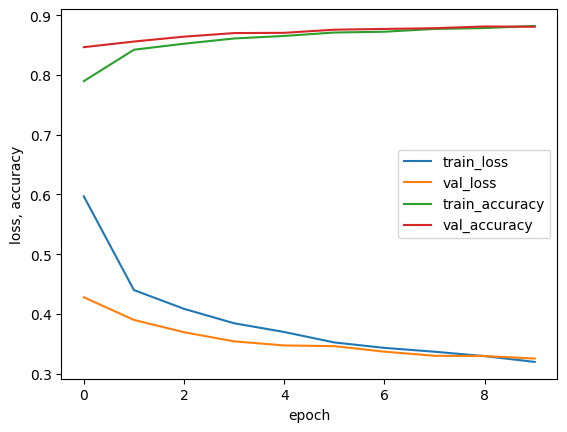

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8872 - loss: 0.3197


[0.31957241892814636, 0.8879166841506958]

In [31]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('epoch')
plt.ylabel('loss, accuracy')
plt.legend(['train_loss', 'val_loss','train_accuracy', 'val_accuracy'])
plt.show()
model.evaluate(val_scaled, val_target) # 검증세트의 성능 확인 (33.10%, 87.99%) 에포크 9번
# 결론 20번을 다 돌리고 좋은 점수가 나온 9번째 에포크를 저장함.

In [32]:
# ModelCheckpoint 콜백을 사용하면
# 검증 성능이 가장 좋은 모델을 자동으로 저장할 수 있다.

# 하지만 현재 학습은 여전히 20 epoch까지 계속 진행된다.

# 실제로 모델 학습 그래프를 보면
# 어느 시점 이후부터는 검증 성능이 더 이상 좋아지지 않고
# 오히려 나빠지기 시작하는 경우가 많다.

# 검증 손실(val_loss)이 다시 증가하기 시작한다는 것은
# 모델이 훈련 데이터에 과하게 맞춰지고 있다는 의미이며
# 과대적합(overfitting)이 시작되었다는 신호이다.


# 이런 경우 이후의 학습은
# 모델 성능을 개선하지 못하면서
# 시간과 컴퓨터 자원만 더 사용하게 된다.


# 그래서 사용하는 방법이 "조기 종료(Early Stopping)"이다.

# EarlyStopping은
# 검증 성능이 더 이상 개선되지 않으면
# 학습을 자동으로 중단하는 기법이다.


# 이 방법의 장점
# 1️⃣ 불필요한 학습을 줄여 시간과 자원을 절약할 수 있다.
# 2️⃣ 과대적합이 심해지기 전에 학습을 멈출 수 있다.


# 따라서 EarlyStopping은
# 에포크 수를 자동으로 조절해주는 역할을 하며
# 딥러닝에서 매우 자주 사용하는 규제(regularization) 방법 중 하나이다.

In [33]:
# 케라스에는 조기 종료(Early Stopping)를 위한 EarlyStopping 콜백이 제공된다.
# EarlyStopping은 검증 성능이 더 이상 좋아지지 않으면
# 자동으로 학습을 중단하는 기능을 한다.

# patience 매개변수
# 검증 성능이 좋아지지 않더라도 몇 번의 epoch까지 기다릴지 설정한다.
# 예: patience=2
# → 검증 성능이 2번 연속 개선되지 않으면 학습을 중지한다.

# restore_best_weights=True
# 학습이 중단된 후 현재 모델의 가중치를
# "가장 좋은 검증 성능을 냈던 시점의 가중치"로 되돌린다.


# Dropout이 포함된 모델 생성
model = model_fn(keras.layers.Dropout(0.3))

# 모델 학습 설정
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


# ModelCheckpoint 콜백
# 검증 성능이 가장 좋았던 모델을 파일로 저장한다.
checkpoint_cb = keras.callbacks.ModelCheckpoint(
    'best-model.keras',
    save_best_only=True
)


# EarlyStopping 콜백
# 검증 성능이 개선되지 않으면 학습을 중단한다.
early_stopping_cb = keras.callbacks.EarlyStopping(
    patience=2,
    restore_best_weights=True
)


# 모델 학습
# callbacks에 두 개의 콜백을 함께 전달한다.
# - ModelCheckpoint : 가장 좋은 모델 저장
# - EarlyStopping : 성능이 나빠지면 학습 중단
history = model.fit(train_scaled, train_target,
                    epochs=20,
                    verbose=1,
                    validation_data=(val_scaled, val_target),
                    callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7354 - loss: 0.7767 - val_accuracy: 0.8397 - val_loss: 0.4384
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8342 - loss: 0.4546 - val_accuracy: 0.8594 - val_loss: 0.3902
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8507 - loss: 0.4119 - val_accuracy: 0.8618 - val_loss: 0.3742
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8598 - loss: 0.3882 - val_accuracy: 0.8633 - val_loss: 0.3650
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8649 - loss: 0.3674 - val_accuracy: 0.8749 - val_loss: 0.3459
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8684 - loss: 0.3555 - val_accuracy: 0.8777 - val_loss: 0.3363
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8736 - loss: 0.3453 - val_accuracy: 0.8780 - val_loss: 0.3312
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8776 - loss: 0.3336 - 

In [34]:
print(early_stopping_cb.stopped_epoch)  # 조기종료 시점 에포크

16


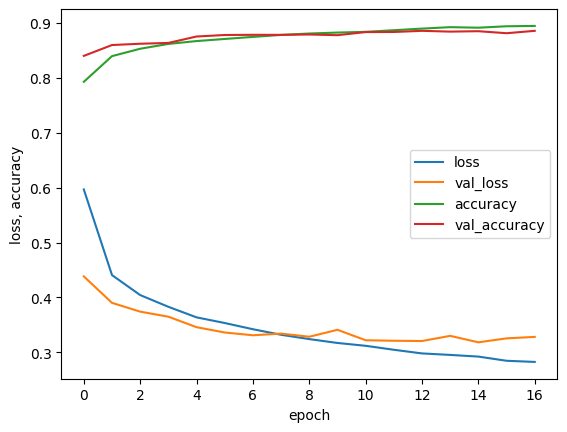

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8854 - loss: 0.3164


[0.31839001178741455, 0.8845833539962769]

In [35]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('epoch')
plt.ylabel('loss, accuracy')
plt.legend(['loss', 'val_loss','accuracy', 'val_accuracy'])
plt.show()
model.evaluate(val_scaled, val_target) # 검증세트의 성능 확인 (32.49%, 88.09%) 에포크 10번
# 컴퓨터의 자원과 시간을 아끼고 콜백과 함꼐 사용하면 최상의 모델을 자동으로 저장해 준다는 것을 명심